In [19]:
from pathlib import Path
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / ".projectroot").exists())

# Model 2: Monthly Unrest Anomaly Detector (GDELT)

Unsupervised monthly detection of emerging unrest. Each country is compared to its own recent normal, and three methods flag abnormal months: a robust z-score baseline, an Isolation Forest, and a Local Outlier Factor. This is coincident to short-lead detection, not long-range prediction.

**Input:** `data/interim/gdelt/gdelt_clean.csv` and `data/processed/master_v1.csv` (country names).
**Output:** `data/processed/anomaly_scores_monthly.csv` (scores and flags per country-month).

In [20]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 220, 'savefig.bbox': 'tight',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.labelsize': 11,
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#ECECEC', 'grid.linewidth': 0.7,
    'axes.axisbelow': True, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False, 'legend.frameon': False,
})
NAVY, BLUE, TEAL, RED, GREEN, GREY = '#1F3864', '#2E75B6', '#2A9D8F', '#C0392B', '#5CB85C', '#BBBBBB'

g = pd.read_csv(str(ROOT / "data/interim/gdelt/gdelt_clean.csv"))
g['month'] = pd.to_datetime(g['month'])
g = g[g['month'] <= '2026-05-01'].sort_values(['iso3', 'month']).reset_index(drop=True)
names = (pd.read_csv(str(ROOT / "data/processed/master_v1.csv"))[['iso3','country']]
           .dropna().drop_duplicates('iso3'))
g = g.merge(names, on='iso3', how='left')
print('rows:', len(g), '| countries:', g.iso3.nunique(), '| span:', g.month.min().date(), '->', g.month.max().date())

rows: 32391 | countries: 239 | span: 2015-02-01 -> 2026-05-01


## 1. Signals

Seven GDELT signals that move when a country escalates: event volume and interstate-conflict count for the surge, Goldstein, tone, and the conflict shares for the severity. Volume signals are log-compressed so large countries do not dominate.

In [21]:
SIGNALS = ['gdelt_event_count', 'bilateral_conflict_events', 'gdelt_violence_share',
           'gdelt_threat_share', 'gdelt_material_conflict_share', 'gdelt_avg_goldstein', 'gdelt_avg_tone']
g['bilateral_conflict_events'] = g['bilateral_conflict_events'].fillna(0)
for c in ['gdelt_event_count', 'bilateral_conflict_events']:
    g[c + '_log'] = np.log1p(g[c])
print('signals:', SIGNALS)

signals: ['gdelt_event_count', 'bilateral_conflict_events', 'gdelt_violence_share', 'gdelt_threat_share', 'gdelt_material_conflict_share', 'gdelt_avg_goldstein', 'gdelt_avg_tone']


## 2. Each country's own normal: robust rolling baseline

For each signal, a robust deviation: how many MADs this month sits above the country's trailing 12-month median, lagged one month. Median and MAD keep one spike from inflating the baseline. Goldstein and tone are sign-flipped so up always means worse.

In [22]:
WIN = 12
def robust_dev(s):
    med = s.shift(1).rolling(WIN, min_periods=6).median()
    mad = (s.shift(1).rolling(WIN, min_periods=6)
             .apply(lambda w: np.median(np.abs(w - np.median(w))), raw=True)).replace(0, np.nan)
    return (s - med) / (1.4826 * mad)

dev = []
for c in SIGNALS:
    src = c + '_log' if c in ['gdelt_event_count', 'bilateral_conflict_events'] else c
    d = g.groupby('iso3', group_keys=False)[src].apply(robust_dev)
    if c in ['gdelt_avg_goldstein', 'gdelt_avg_tone']:
        d = -d
    g[c + '_dev'] = d; dev.append(c + '_dev')
print('deviation features:', dev)
print('scored rows (after 6-mo warmup):', int(g[dev].notna().any(axis=1).sum()))

deviation features: ['gdelt_event_count_dev', 'bilateral_conflict_events_dev', 'gdelt_violence_share_dev', 'gdelt_threat_share_dev', 'gdelt_material_conflict_share_dev', 'gdelt_avg_goldstein_dev', 'gdelt_avg_tone_dev']
scored rows (after 6-mo warmup): 29523


## 3. Three methods, same inputs

All three score the same deviation matrix, so only the method differs. The z-score flags any month above 1.5 MADs, an interpretable recall-leaning bar. The Isolation Forest and LOF flag the top 10 percent, the conventional percentile threshold. All three sit near a 10 percent flag rate so the comparison is fair.

In [23]:
D = g[dev].clip(-10, 10).fillna(0).values

g['m1_zscore'] = np.clip(g[dev].fillna(0).values, 0, None).mean(axis=1)
g['m2_iforest'] = -IsolationForest(n_estimators=300, contamination=0.05,
                                   random_state=42, n_jobs=-1).fit(D).score_samples(D)
g['m3_lof'] = -LocalOutlierFactor(n_neighbors=20, contamination=0.05).fit(D).negative_outlier_factor_

METHODS = ['m1_zscore', 'm2_iforest', 'm3_lof']
THRESH = {'m1_zscore': 1.5,
          'm2_iforest': g['m2_iforest'].quantile(0.90),
          'm3_lof':     g['m3_lof'].quantile(0.90)}
for m in METHODS:
    g[m + '_flag'] = (g[m] >= THRESH[m]).astype(int)
    g[m + '_pr'] = g.groupby('month')[m].rank(pct=True)
print('thresholds:', {k: round(v, 3) for k, v in THRESH.items()})
print('total flags per method (and % of all country-months):')
for m in METHODS:
    print('  %-11s %5d  (%.1f%%)' % (m, g[m + '_flag'].sum(), 100 * g[m + '_flag'].mean()))

thresholds: {'m1_zscore': 1.5, 'm2_iforest': 0.48, 'm3_lof': 1.246}
total flags per method (and % of all country-months):
  m1_zscore    3078  (9.5%)
  m2_iforest   3240  (10.0%)
  m3_lof       3240  (10.0%)


## 4. Validation: known crisis onsets

No accuracy label exists, so I test against a hand-built list of 50 datable crisis onsets. For each method I measure detection (did the country cross its bar within -3 to +1 months of the onset) and lead (months before the onset it first fired).

In [24]:
ONSETS = [
 ('UKR',2022,2,'Russia invasion'),('MMR',2021,2,'coup'),('NER',2023,7,'coup'),('SDN',2023,4,'RSF\u2013SAF war'),
 ('AFG',2021,8,'Taliban takeover'),('ETH',2020,11,'Tigray war'),('MLI',2021,5,'coup'),('BFA',2022,1,'coup'),
 ('LKA',2022,4,'economic crisis'),('KAZ',2022,1,'unrest'),('ISR',2023,10,'Gaza war'),('ARM',2020,9,'Karabakh'),
 ('YEM',2015,3,'Saudi intervention'),('GIN',2021,9,'coup'),('BLR',2020,8,'protests'),('IRN',2022,9,'Amini protests'),
 ('AZE',2020,9,'Karabakh'),('SSD',2016,7,'civil war'),
 ('FRA',2015,11,'Paris attacks'),('BEL',2016,3,'Brussels bombings'),('TUR',2016,7,'coup attempt'),
 ('CMR',2017,10,'Anglophone crisis'),('MOZ',2017,10,'Cabo Delgado insurgency'),('NIC',2018,4,'protests'),
 ('FRA',2018,11,'yellow vests'),('VEN',2019,1,'presidential crisis'),('NZL',2019,3,'Christchurch attack'),
 ('LKA',2019,4,'Easter bombings'),('LBY',2019,4,'Tripoli offensive'),('SDN',2019,4,'revolution'),
 ('HKG',2019,6,'protests'),('ECU',2019,10,'protests'),('CHL',2019,10,'estallido'),('LBN',2019,10,'protests'),
 ('IRQ',2019,10,'Tishreen protests'),('IRN',2019,11,'fuel protests'),('USA',2020,5,'George Floyd protests'),
 ('MOZ',2021,3,'Palma attack'),('COL',2021,4,'protests'),('TCD',2021,4,'D\u00e9by death'),('CUB',2021,7,'protests'),
 ('TUN',2021,7,'Saied power grab'),('SDN',2021,10,'al-Burhan coup'),('TWN',2022,8,'Pelosi tensions'),
 ('BFA',2022,9,'second coup'),('AZE',2023,9,'Karabakh offensive'),('GAB',2023,8,'coup'),
 ('PAK',2023,1,'Peshawar bombing'),('BGD',2024,7,'protests/ouster'),('KEN',2024,6,'protests')]
g['ym'] = g.month.dt.year * 12 + g.month.dt.month

rows = []
for m in METHODS:
    hits, leads = 0, []
    for iso, yr, mo, _ in ONSETS:
        t = yr * 12 + mo
        sub = g[(g.iso3 == iso) & (g.ym.between(t - 3, t + 1))]
        fl = sub[sub[m + '_flag'] == 1]
        if len(fl):
            hits += 1; leads.append(t - int(fl.ym.min()))
    rows.append({'method': m, 'detected': f'{hits}/{len(ONSETS)}',
                 'detection_rate': round(hits/len(ONSETS), 2),
                 'median_lead_mo': float(np.median(leads)) if leads else 0.0})
comp = pd.DataFrame(rows)
print(comp.to_string(index=False))

    method detected  detection_rate  median_lead_mo
 m1_zscore    43/50            0.86             0.0
m2_iforest    43/50            0.86             0.0
    m3_lof    17/50            0.34             2.0


The z-score baseline and Isolation Forest tie at 43 of 50, LOF fails at 17 of 50 because density methods degrade in many dimensions. A transparent statistical method matches the ML detector, so I keep both. This is recall only, not precision, the false-alarm rate needs a full conflict label set like ACLED, noted as future work.

### 4a. Does it beat chance? (permutation test)

Keep the flags fixed, assign each onset country a random month, count catches, and repeat 2,000 times. Then compare the real result to that chance distribution.

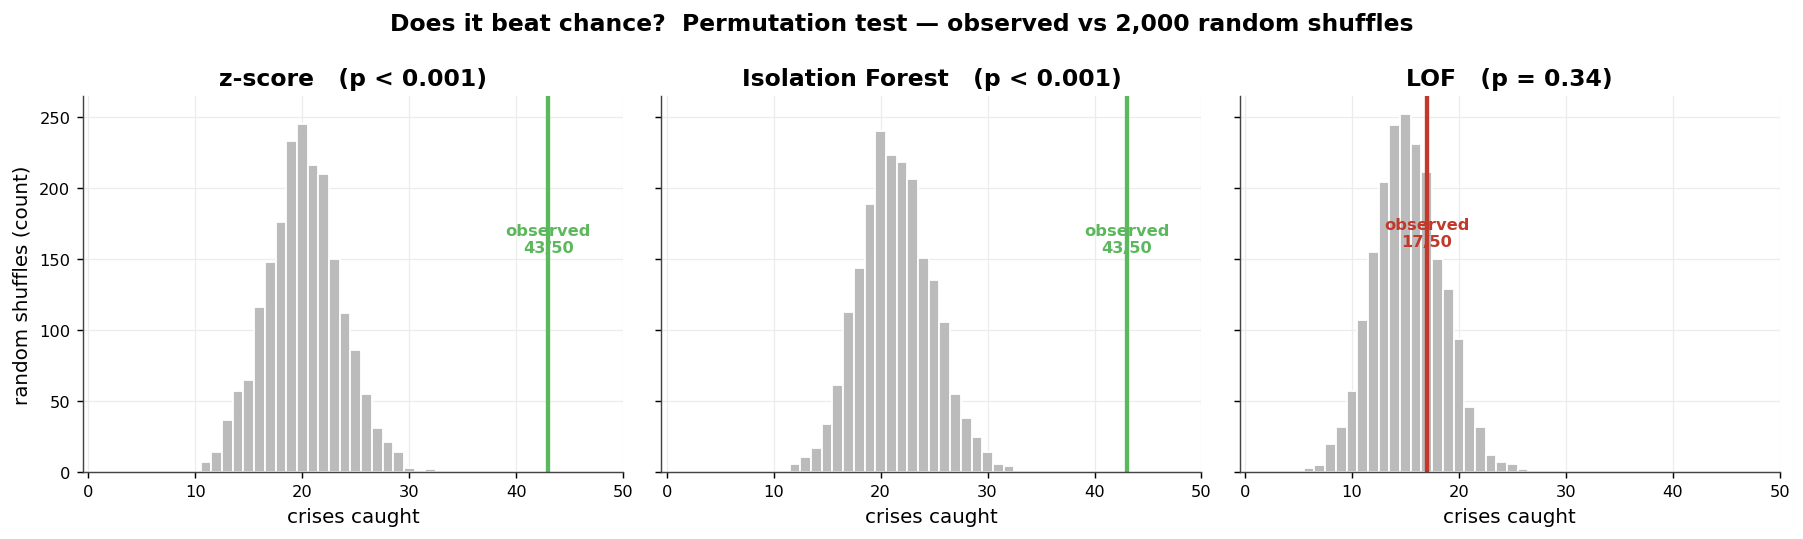

In [25]:
LABELS = {'m1_zscore': 'z-score', 'm2_iforest': 'Isolation Forest', 'm3_lof': 'LOF'}
flagsets = {m: g[g[m + '_flag'] == 1].groupby('iso3')['ym'].apply(set).to_dict() for m in METHODS}
yr_rng = g.groupby('iso3')['ym'].agg(['min', 'max']).to_dict('index')
def _caught(iso, t, fs): return any((t - 3) <= y <= (t + 1) for y in fs.get(iso, set()))
rng = np.random.default_rng(42); N = 2000
fig, axes = plt.subplots(1, len(METHODS), figsize=(14, 4.2), sharey=True)
for ax, m in zip(axes, METHODS):
    fs = flagsets[m]
    actual = sum(_caught(iso, yr * 12 + mo, fs) for iso, yr, mo, _ in ONSETS)
    null = np.empty(N)
    for i in range(N):
        s = 0
        for iso, yr, mo, _ in ONSETS:
            r = yr_rng.get(iso)
            if r: s += _caught(iso, int(rng.integers(r['min'] + 12, r['max'] + 1)), fs)
        null[i] = s
    p = (null >= actual).mean()
    col = GREEN if p < 0.05 else RED
    ax.hist(null, bins=np.arange(-0.5, len(ONSETS) + 1, 1), color=GREY, edgecolor='white')
    ax.axvline(actual, color=col, lw=2.4)
    ax.annotate(f'observed\n{actual}/{len(ONSETS)}', xy=(actual, 0),
                xytext=(actual, ax.get_ylim()[1] * 0.6), ha='center', fontsize=9, color=col, fontweight='bold')
    ax.set_title(f'{LABELS[m]}   (p {"< 0.001" if p < 0.001 else f"= {p:.2f}"})')
    ax.set_xlabel('crises caught'); ax.set_xlim(-0.5, len(ONSETS))
axes[0].set_ylabel('random shuffles (count)')
fig.suptitle('Does it beat chance?  Permutation test \u2014 observed vs 2,000 random shuffles',
             fontsize=13, fontweight='bold')
fig.tight_layout(); plt.show()

z-score and Isolation Forest land far in the empty tail, 43 of 50 against about 20 by chance, p < 0.001, real skill rather than over-flagging. LOF sits inside its own random cloud, no better than chance.

## 5. Lead time: early warning or coincident?

Monthly z-score for Ukraine and Russia around the 2022 invasion, with the alert bar and onset marked. The z-score is used because its axis is in MAD units, so spike height and threshold are both readable.

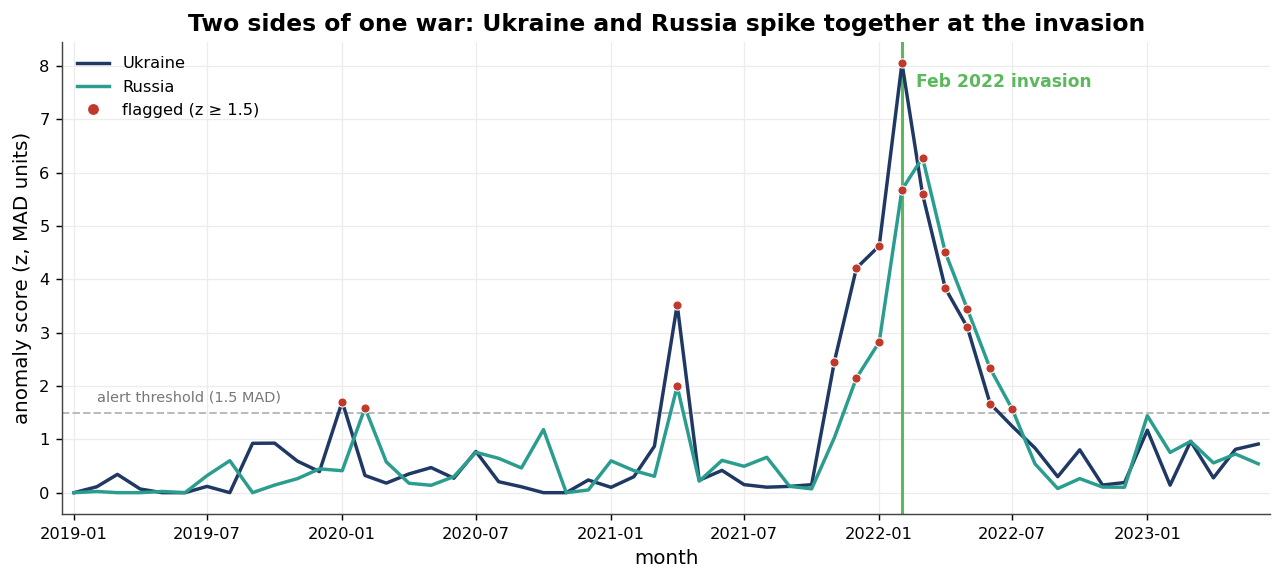

In [26]:
from matplotlib.lines import Line2D
onset = pd.Timestamp('2022-02-01')
fig, ax = plt.subplots(figsize=(10, 4.6))
for iso, col, name in [('UKR', NAVY, 'Ukraine'), ('RUS', TEAL, 'Russia')]:
    d = g[(g.iso3 == iso) & (g.month >= '2019-01-01') & (g.month <= '2023-06-01')].sort_values('month')
    ax.plot(d.month, d.m1_zscore, color=col, lw=1.9, label=name, zorder=2)
    fl = d[d.m1_zscore_flag == 1]
    ax.scatter(fl.month, fl.m1_zscore, color=RED, s=26, zorder=4, edgecolor='white', linewidth=.6)
ax.axhline(1.5, color=GREY, ls='--', lw=1.1, zorder=1)
ax.text(pd.Timestamp('2019-02-01'), 1.65, 'alert threshold (1.5 MAD)', color='#777', fontsize=8, va='bottom')
ax.axvline(onset, color=GREEN, lw=1.7, zorder=1)
ax.annotate('Feb 2022 invasion', xy=(onset, ax.get_ylim()[1] * 0.93), xytext=(8, 0),
            textcoords='offset points', color=GREEN, fontsize=9.5, fontweight='bold', va='top')
handles = [Line2D([0], [0], color=NAVY, lw=1.9, label='Ukraine'),
           Line2D([0], [0], color=TEAL, lw=1.9, label='Russia'),
           Line2D([0], [0], marker='o', color='w', markerfacecolor=RED,
                  markeredgecolor='white', markersize=7, label='flagged (z \u2265 1.5)')]
ax.legend(handles=handles, fontsize=9, loc='upper left')
ax.set_ylabel('anomaly score (z, MAD units)'); ax.set_xlabel('month')
ax.set_title('Two sides of one war: Ukraine and Russia spike together at the invasion')
ax.margins(x=0.01)
fig.tight_layout(); plt.show()

Ukraine sits near zero for years, then its first alert fires about three months before the invasion, the buildup was visible. Russia spikes with it at the onset, the detector sees both sides of one event. Abrupt events like coups have no such buildup and fire in the same month (see the lead column in section 4).

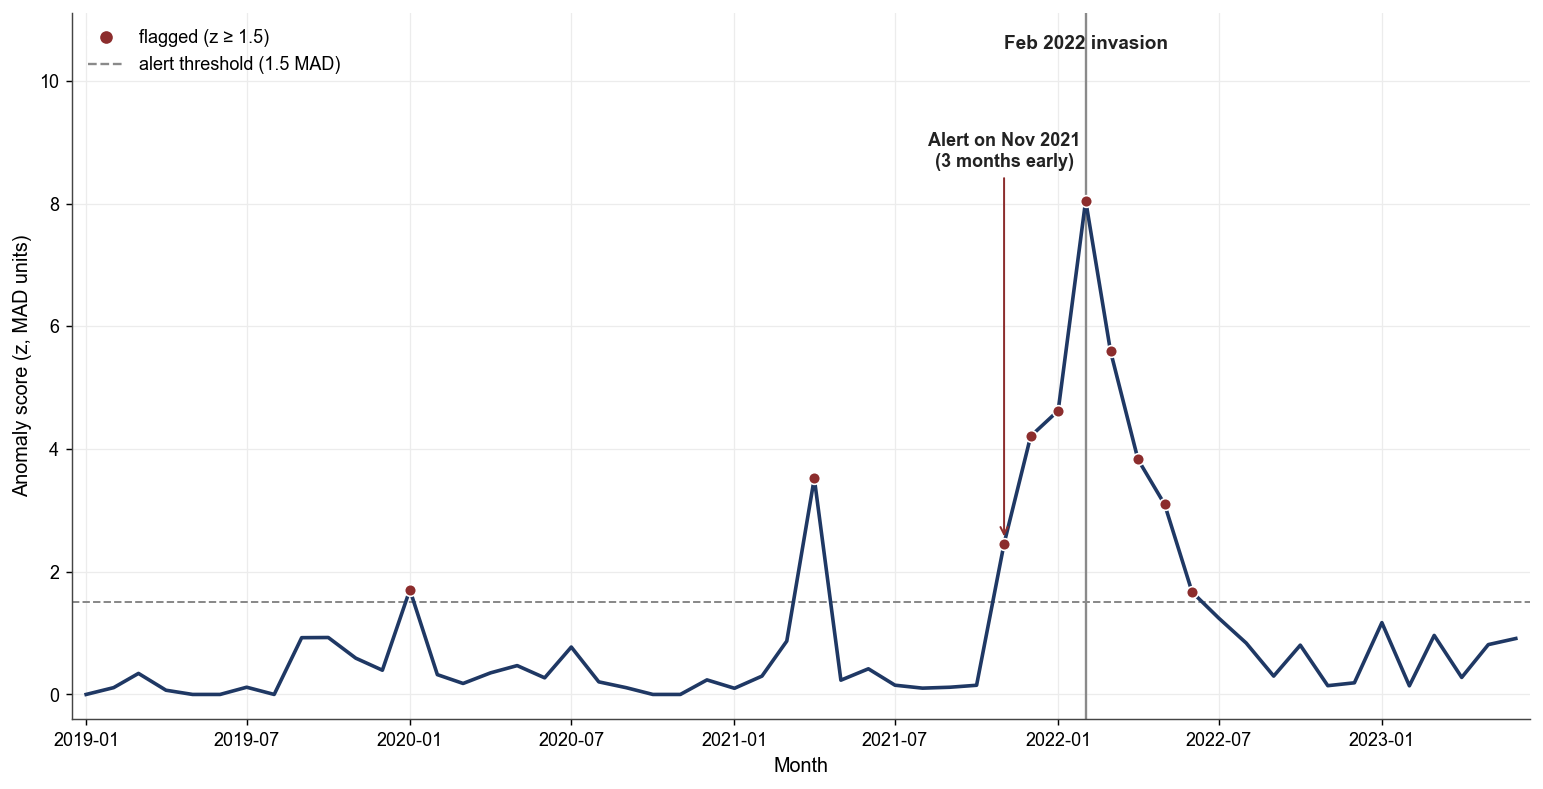

saved /Users/oussamaennaciri/Documents/Education/Academique/Regis/MSDS692 S40 Data Science Practicum/reports/proposal/figures/anomaly_ukraine_2022.png


In [32]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

FIG_DIR = ROOT / "reports/proposal/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# APA figure style: sans-serif, no embedded title/caption, high-res output
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#ECECEC', 'grid.linewidth': 0.7,
    'axes.axisbelow': True, 'axes.spines.top': False, 'axes.spines.right': False,
    'legend.frameon': False,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'axes.labelsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

# Reduced palette: one neutral, one accent — no green, no separate teal
NAVY   = '#1F3864'   # primary series
MAROON = '#8C2D2D'   # flagged points + key accent (used sparingly)
GREY   = '#8A8A8A'   # threshold, invasion marker, neutral text

onset = pd.Timestamp('2022-02-01')
d = (g[(g.iso3 == 'UKR') & (g.month >= '2019-01-01') & (g.month <= '2023-06-01')]
       .sort_values('month').reset_index(drop=True))

fig, ax = plt.subplots(figsize=(12, 6.2))

ax.plot(d.month, d.m1_zscore, color=NAVY, lw=2.0, zorder=2)
fl = d[d.m1_zscore_flag == 1]
ax.scatter(fl.month, fl.m1_zscore, color=MAROON, s=42, zorder=4, edgecolor='white', linewidth=0.9)
ax.axhline(1.5, color=GREY, ls='--', lw=1.1, zorder=1)
ax.axvline(onset, color=GREY, lw=1.3, zorder=1)

# locate the start of the sustained flagged run leading into the invasion
flagged_idx = set(d.index[d.m1_zscore_flag == 1])
onset_idx = d.index[d.month <= onset].max()
start_idx = onset_idx
while (start_idx - 1) in flagged_idx:
    start_idx -= 1
sustained_start = d.loc[start_idx, 'month']
sustained_val = d.loc[start_idx, 'm1_zscore']
months_early = (onset.year * 12 + onset.month) - (sustained_start.year * 12 + sustained_start.month)

# Expand headroom above the data and place BOTH labels up there, staggered
# in height — since nothing in the series exceeds ymax, no text can ever
# cross the line; only the short vertical leader arrows dip into the plot,
# each at a single x-value, so they can't cross the curve elsewhere.
ymax = d.m1_zscore.max()
ax.set_ylim(top=ymax * 1.38)

ax.annotate('Feb 2022 invasion', xy=(onset, ymax), xytext=(onset, ymax * 1.30),
            ha='center', va='bottom', color='#222222', fontsize=10.5, fontweight='semibold')

ax.annotate(
    f'Alert on {sustained_start.strftime("%b %Y")}\n({months_early} months early)',
    xy=(sustained_start, sustained_val),
    xytext=(sustained_start, ymax * 1.06),
    ha='center', va='bottom', color='#222222', fontsize=10, fontweight='semibold',
    arrowprops=dict(arrowstyle='->', color=MAROON, lw=1.1, shrinkA=2, shrinkB=4)
)

handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=MAROON, markeredgecolor='white',
           markersize=8, label='flagged (z \u2265 1.5)'),
    Line2D([0], [0], color=GREY, ls='--', lw=1.3, label='alert threshold (1.5 MAD)'),
]
ax.legend(handles=handles, fontsize=10, loc='upper left')

ax.set_ylabel('Anomaly score (z, MAD units)')
ax.set_xlabel('Month')
ax.margins(x=0.01)

fig.tight_layout()
fig.savefig(str(FIG_DIR / 'anomaly_ukraine_2022.png'), dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
print('saved', FIG_DIR / 'anomaly_ukraine_2022.png')

## 6. Score every country-month and save

Save all three scores and flags. The top recent alerts (Isolation Forest) are the product.

In [27]:
out = g[['iso3', 'country', 'month'] + METHODS + [m + '_flag' for m in METHODS]].copy()
out.to_csv(str(ROOT / "data/processed/anomaly_scores_monthly.csv"), index=False)
print('saved anomaly_scores_monthly.csv |', len(out), 'country-months')
print()
recent = g[(g.month >= '2025-06-01') & (g.m2_iforest_flag == 1)]
print('=== Unrest alerts, last 12 months (Isolation Forest, fixed bar) ===')
print(recent.nlargest(12, 'm2_iforest')[['country', 'month', 'm2_iforest']]
        .assign(month=lambda d: d.month.dt.strftime('%Y-%m')).round(3).to_string(index=False))

saved anomaly_scores_monthly.csv | 32391 country-months

=== Unrest alerts, last 12 months (Isolation Forest, fixed bar) ===
             country   month  m2_iforest
             Bahrain 2026-03       0.783
              Cyprus 2026-03       0.775
              Kuwait 2026-03       0.774
United Arab Emirates 2026-03       0.758
             Lebanon 2026-03       0.758
        Saudi Arabia 2026-03       0.758
              Kuwait 2026-04       0.754
             Bahrain 2026-02       0.751
             Austria 2025-06       0.745
              Poland 2025-09       0.743
               Qatar 2026-03       0.735
           Australia 2025-12       0.725


Claude (Anthropic) was used only as a collaborator for writing code and polishing the notebooks. All analytical decisions, interpretations, and research were conducted independently by me.